<a href="https://colab.research.google.com/github/curingd/mean-variance-optimisation/blob/main/MVO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mean-Variance Portfolio Optimisation
## Theory
Mean-Variance Optimisation (MVO) is a method for determining position weights in investment portfolios with an optimal Sharpe Ratio (SR), given a "risk-free rate" (usually the yield-to-maturity of a government bond) and individual stock returns and their covariances.

The SR (Sharpe, 1966) of a portfolio is given as:

$SR_{p} = \frac{E(R_p)-R_f}{\sigma_{p}}$

Where:

$E(R_p) = $ expected portfolio return

$R_f = $ risk-free rate

$\sigma_{p} = $ portfolio standard deviation

In essence, the SR is a measure of excess return per unit of risk exposure.

Given a portfolio P with an optimal SR, an investor may leverage (or deleverage) P by borrowing (or lending) at the risk-free rate to obtain a portfolio consistent with their individual level of risk tolerance and achieving the highest expected return possible for that level of risk exposure.



##Practice

Coding methods for implementing MVO in Python include:

*   Trial and error
*   Manually customised gradient descent (with or without Lagrange multipliers expressing constraints) and adjustments to weights mid-algorithm for stability
*   Use of packages such as `scipy.optimize`, `PyPortfolioOpt` or `CVXPY`

This project will present a customised use of unconstrained gradient descent, where the portfolio weights are parametrised using angles on a $n$-dimensional unit sphere.

MVO can be applied to asset classes or individual securities: this article will illustrate MVO using individual stock returns.

To build a working MVO model, raw price data must first be converted into returns data.

If you wish to use price data from stocks of your own choosing, the following functions pull price data from selected stock tickers using Alpha Vantage and FMP respectively and place them in a pandas dataframe. Insert your own API keys where indicated:

In [ ]:
# Import relevant modules for this project:

import os
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
'''
This function imports stock price data from Alpha Vantage into a pandas dataframe.
Insert your API key into the .env.example file next to ALPHAVANTAGE_API_KEY to be read.
'''

ALPHA_VANTAGE_BASE_URL = "https://www.alphavantage.co/query"

def AV_data(
    function="TIME_SERIES_WEEKLY_ADJUSTED",
    symbol="MSFT",
    output_size="full",
    data_type="json",
):
    """
    Fetches time series stock data from the Alpha Vantage API and returns it
    as a pandas DataFrame.

    Side effects:
    - Performs an external HTTP request to Alpha Vantage
    - Depends on the ALPHAVANTAGE_API_KEY environment variable
    - May fail due to network issues or API rate limits

    Returns:
    - pandas DataFrame containing time series data
    - Empty DataFrame if an API error occurs or no time series data is found
    """

    api_key = os.getenv("ALPHAVANTAGE_API_KEY")
    if not api_key:
        raise RuntimeError("ALPHAVANTAGE_API_KEY environment variable is not set")

    params = {
        "function": function,
        "symbol": symbol,
        "outputsize": output_size,
        "datatype": data_type,
        "apikey": api_key,
    }

    response = requests.get(ALPHA_VANTAGE_BASE_URL, params=params, timeout=10)
    response.raise_for_status()
    data = response.json()

    if "Error Message" in data:
        print(f"Alpha Vantage API error for {symbol}: {data['Error Message']}")
        return pd.DataFrame()

    if "Note" in data:
        print(f"Alpha Vantage API note for {symbol}: {data['Note']}")

    for key in data.keys():
        if "Time Series" in key:
            df = pd.DataFrame(data[key]).transpose()
            df.index = pd.to_datetime(df.index)
            return df

    print(
        f"No 'Time Series' data found in Alpha Vantage response for {symbol}. "
        f"Response keys: {list(data.keys())}"
    )
    return pd.DataFrame()

In [ ]:
'''
This function imports stock price data from FMP into a pandas dataframe.
Insert your API key into the .env.example file next to FMP_API_KEY to be read.
'''

FMP_BASE_URL = "https://financialmodelingprep.com/stable"

def FMP_data(
    symbol="MSFT",
    category="historical-price-eod",
    subcategory="dividend-adjusted",
    start_date=None,
    end_date=None,
):
    """
    Fetches stock price data from the Financial Modeling Prep API.

    Side effects:
    - Performs an external HTTP request
    - Depends on the FMP_API_KEY environment variable
    """

    api_key = os.getenv("FMP_API_KEY")
    if not api_key:
        raise RuntimeError("FMP_API_KEY environment variable is not set")

    url = f"{FMP_BASE_URL}/{category}/{subcategory}"
    params = {"symbol": symbol, "apikey": api_key}

    if start_date is not None:
        params["from"] = str(start_date)
    if end_date is not None:
        params["to"] = str(end_date)

    response = requests.get(url, params=params, timeout=10)
    response.raise_for_status()
    data = response.json()

    if isinstance(data, dict) and "error" in data:
        print(f"FMP API error for {symbol}: {data['error']}")
        return pd.DataFrame()

    return pd.DataFrame(data)

For ease of use, here MVO will be applied to the following returns series using weekly adjusted-close price data for the period 1st Feb 2016 to 1st Feb 2026 from the following 5 large-cap stocks in distinct economic sectors: Google (ticker GOOGL), Target (TGT), Nike (NKE), Visa (V) and General Motors (GM).

Price data is also converted to returns data:

In [ ]:
# Import weekly price data:
stock_prices = pd.read_csv("stock_prices.csv")

# Convert all columns except 'date' to numeric type
numeric_cols = ['GOOGL', 'TGT', 'NKE', 'V', 'GM']
for col in numeric_cols:
    stock_prices[col] = pd.to_numeric(stock_prices[col], errors='coerce')

# Convert 'date' column to datetime and set it as index
stock_prices['date'] = pd.to_datetime(stock_prices['date'])
stock_prices = stock_prices.set_index('date')

print(stock_prices.head(10))

# Converting price data to returns data:
stock_returns = stock_prices.pct_change().dropna()

print(stock_returns.head(10))

# Keep compatibility with later cells that expect lists
GOOGL_returns = stock_returns["GOOGL"].tolist()
TGT_returns = stock_returns["TGT"].tolist()
NKE_returns = stock_returns["NKE"].tolist()
V_returns = stock_returns["V"].tolist()
GM_returns = stock_returns["GM"].tolist()

# Matrix form for optimisation code
returns_matrix = stock_returns.to_numpy()
tickers = stock_returns.columns.tolist()


              GOOGL      TGT      NKE        V       GM
date                                                   
2016-02-07  34.9220  51.6315  50.3380  66.7000  22.9577
2016-02-14  35.0773  52.3366  49.6776  65.6558  22.2900
2016-02-21  35.8325  54.1098  52.2223  66.8203  23.1507
2016-02-28  35.9690  58.6814  55.1191  67.9413  23.8345
2016-03-06  36.2350  60.7015  54.0797  69.0343  25.2341
2016-03-13  36.9619  61.2552  53.0380  66.9137  25.4585
2016-03-20  37.4849  61.8836  55.6069  68.9222  26.0286
2016-03-27  37.4567  61.3824  54.4239  69.2585  25.2142
2016-04-03  38.1926  61.9211  54.3710  72.4813  24.8152
2016-04-10  37.6864  60.5144  52.4553  72.8923  23.9193
               GOOGL       TGT       NKE         V        GM
date                                                        
2016-02-14  0.004447  0.013656 -0.013119 -0.015655 -0.029084
2016-02-21  0.021530  0.033881  0.051224  0.017736  0.038614
2016-02-28  0.003809  0.084487  0.055471  0.016776  0.029537
2016-03-06  0.007395  0

The next step is to define in code the key function (SR) to be used for MVO.



Expected return and standard deviation are calculated at the portfolio level here, using stock weightings as inputs:

In [ ]:
def sharpe_ratio(weights, returns_matrix, risk_free_rate):

  # Converting lists to numpy arrays:
  weights_array = np.array(weights)
  returns_array = np.array(returns_matrix)

  # Computing portfolio expected return and standard deviation, handling errors:
  try:
    portfolio_returns = np.dot(weights_array.T, returns_array)
  except ValueError:
    print(f"weights={weights} must have same number of rows as returns_matrix")
    return

  portfolio_return = portfolio_returns.mean()
  portfolio_std = portfolio_returns.std()

  return (portfolio_return - risk_free_rate) / portfolio_std

Portfolio weights will be explicitly parameterised using $n$-dimensional spherical polars.

Each weight is the square of a component of a Cartesian co-ordinate on a unit $n$-sphere, so that weights always sum to 1:

$ w_{i} =
\begin{cases}
\cos^2 \phi_{1} \qquad \qquad \qquad \qquad \quad  i=1 \\
\sin^2 \phi_{1} \dots \sin^2 \phi_{i-1} \cos^2 \phi_{i} \qquad 1<i<n \\
\sin^2 \phi_{1} \dots  \sin^2 \phi_{n-1} \qquad \qquad \, \, \, i=n
\end{cases}
$


Below is a function that returns weights from the $(n-1)$ angles required:

In [ ]:
def weights_from_angles(angle_list):

  # Obtaining number of output weights:
  num_weights = len(angle_list) + 1

  # Building up sin^2 and cos^2 calculations:
  weights = []
  sin_squared_list = [np.sin(angle)**2 for angle in angle_list]
  cos_squared_list = [np.cos(angle)**2 for angle in angle_list]
  cumulative_sin_squared_list = [np.prod(sin_squared_list[:i+1]) for i in range(len(sin_squared_list))]

  # If i=1:
  weights.append(np.cos(angle_list[0])**2)

  # If 1<i<n:
  for i in range(1, num_weights-1):
    weights.append(cumulative_sin_squared_list[i-1] * cos_squared_list[i])

  # If i=n:
  weights.append(cumulative_sin_squared_list[-1])

  return weights

Below is the function used for gradient descent:

In [ ]:
# This code defines the gradient descent process in the abstract.

def gradient_descent(starting_vector, function, learning_rate, num_iterations):

  # Ensuring valid values of learning_rate and num_iterations:
  if learning_rate <= 0 or type(num_iterations) != int or num_iterations <= 0:
    raise ValueError("learning_rate must be a positive number and/or num_iterations must be a positive integer")
    return

  # Initialising parameters:
  n = len(starting_vector)
  gradient = []
  starting_vector = np.array(starting_vector)
  current_vector = starting_vector

  for i in range(num_iterations):

    for j in range(n):

      # Computing the partial derivatives of the function:
      delta_plus = np.array([0 if k != j else 0.0001 for k in range(n)])
      delta_minus = np.array([0 if k != j else -0.0001 for k in range(n)])

      # Ensuring starting_vector compatible with function:
      try:
        partial_derivative = (function(np.array(current_vector + delta_plus).tolist()) - function(np.array(current_vector + delta_minus).tolist())) / 0.0002
      except ValueError:
        print(f"function={function} cannot take starting_vector={starting_vector} as an argument")
        return

      gradient.append(partial_derivative)

    # Gradient descent step:
    current_vector = current_vector - learning_rate * np.array(gradient)

    gradient = []

  return current_vector.tolist()

Now we will construct the MVO function which incorporates the unconstrained gradient descent:

In [ ]:
# This code defines the MVO process using the gradient descent function, subject to sum of weights equalling 1.

def MVO(returns_array, learning_rate, num_iterations, risk_free_rate):
  # Converting returns list to a numpy array:
  returns_array = np.array(returns_array)

  # Randomising starting angles:
  starting_angles = np.random.uniform(low=0, high=2*np.pi, size=returns_array.shape[0]-1)
  starting_angles = starting_angles.tolist()

  # Function to be freely optimised. In this case, the (-) ensures better convergence to a stationary point:
  function = lambda a: -sharpe_ratio(weights_from_angles(a), returns_array, risk_free_rate)

  # Gradient descent process:
  output_angles = gradient_descent(starting_angles, function, learning_rate, num_iterations)
  output_weights = weights_from_angles(output_angles)

  # Computing portfolio statistics:
  portfolio_returns = np.dot(output_weights, returns_array)
  portfolio_return = portfolio_returns.mean()*52 # Annualising weekly returns
  portfolio_std = portfolio_returns.std()*np.sqrt(52) # Annualising weekly standard deviation
  portfolio_sr = (portfolio_return - risk_free_rate) / portfolio_std

  output_df = pd.DataFrame({'weights': output_weights, 'portfolio_return': portfolio_return, 'portfolio_std': portfolio_std, 'portfolio_sharpe_ratio': portfolio_sr})

  return output_df

The code below returns the MV-optimised weights and resulting portfolio return, standard deviation and SR:

In [ ]:
risk_free_rate = 0.03
returns_array = [GOOGL_returns, TGT_returns, NKE_returns, V_returns, GM_returns]
MVO_portfolio_df = MVO(returns_array, 1, 10000, risk_free_rate)
MVO_portfolio_df.index = ['GOOGL', 'TGT', 'NKE', 'V', 'GM']

print(MVO_portfolio_df)

            weights  portfolio_return  portfolio_std  portfolio_sharpe_ratio
GOOGL  1.000000e+00          0.263972       0.272617                0.858244
TGT    6.609943e-28          0.263972       0.272617                0.858244
NKE    2.184792e-26          0.263972       0.272617                0.858244
V      2.431932e-27          0.263972       0.272617                0.858244
GM     7.009254e-27          0.263972       0.272617                0.858244


Let's find out if the MVO output is indeed optimal, by plotting portfolio standard deviation and mean pairs from 1000 randomly generated weights.

The optimal portfolio should be on the efficient frontier (top left of the cluster of points) and a line drawn from the point to (0, risk_free_rate) should have the highest gradient, which corresponds to the highest SR:

/tmp/ipython-input-167115102.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  optimised_MV_coords = [MVO_portfolio_df['portfolio_std'][0], MVO_portfolio_df['portfolio_return'][0], MVO_portfolio_df['portfolio_sharpe_ratio'][0]]
/tmp/ipython-input-167115102.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  MV_plot.ax.axline(xy1=(0, risk_free_rate), slope=MVO_portfolio_df['portfolio_sharpe_ratio'][0])


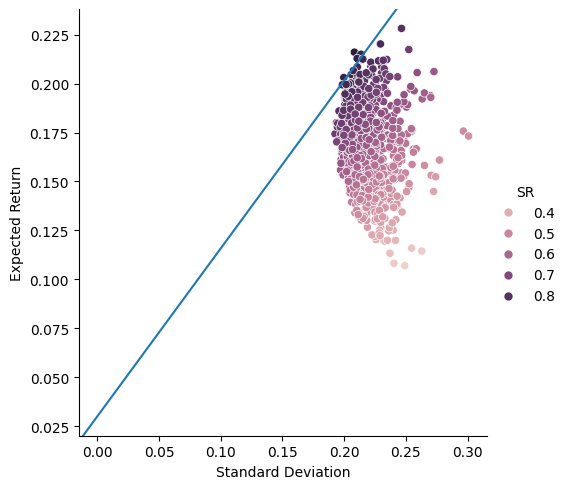

In [ ]:
# Extracting the optimised mean, standard deviation and SR from the data frame:
optimised_MV_coords = [MVO_portfolio_df['portfolio_std'][0], MVO_portfolio_df['portfolio_return'][0], MVO_portfolio_df['portfolio_sharpe_ratio'][0]]

# Generating 1000 other mean and standard deviation co-ordinate pairs using randomised weights:
MV_coords = []

for i in range(1000):

  # Generating random weights:
  other_weights = np.random.rand(len(returns_array))
  other_weights = other_weights / sum(other_weights)

  # Generating portfolio returns series:
  returns_series = np.dot(other_weights, np.array(returns_array))

  # Computing summary statistics:
  mean = returns_series.mean()*52
  std_dev = returns_series.std()*np.sqrt(52)
  SR = (mean - risk_free_rate) / std_dev

  # Adding to list of co-ordinates:
  MV_coords.append([std_dev, mean, SR])

# Creating a data frame from the generated co-ordinates:
data = pd.DataFrame(MV_coords, columns=['std', 'mean', 'SR'])

# Generating a scatter plot of mean against standard deviation, with SR as hue:
MV_plot = sns.relplot(data, x='std', y='mean', hue='SR')
MV_plot.set_axis_labels('Standard Deviation', 'Expected Return')

# Additional line to mark on optimal SR:
MV_plot.ax.axline(xy1=(0, risk_free_rate), slope=MVO_portfolio_df['portfolio_sharpe_ratio'][0])






# Resampled MVO

As the previous algorithm may have shown, MVO can:

*   Be highly sensitive to deviations in expected returns from individual stocks/asset classes
*   Be highly irregular in its output per trial
*   Result in highly concentrated asset allocations

Resampling can help smooth the output allocations and produce less concentrated positions.

Under the resampling method, several series of small deviations are added to each stock return, then the resulting outputs from MVO are averaged to give the final weightings.

The code below defines the resampled MVO function:

In [ ]:
def resampled_MVO(returns_array, learning_rate, num_iterations, risk_free_rate, resample_freq, resample_tolerance):

  output_weights_matrix = []

  # Performing MVO resample_freq times with random noise added:
  for i in range(resample_freq):
    current_returns_matrix = returns_array.copy()
    for return_series in current_returns_matrix:
      for r in return_series:
        r += np.random.uniform(-resample_tolerance, resample_tolerance)

    # Converting returns series into a numpy array:
    returns_array = np.array(returns_array)

    # Randomising starting angles:
    starting_angles = np.random.uniform(low=0, high=2*np.pi, size=returns_array.shape[0]-1)
    starting_angles = starting_angles.tolist()

    # Function to be freely optimised:
    function = lambda a: -sharpe_ratio(weights_from_angles(a), returns_array, risk_free_rate)

    # Gradient descent process:
    output_angles = gradient_descent(starting_angles, function, learning_rate, num_iterations)
    output_weights = weights_from_angles(output_angles)
    output_weights_matrix.append(output_weights)
    returns_array = returns_array.tolist()

  # Taking an average of the resulting weights and computing portfolio statistics:
  aggregated_weights = np.array(output_weights_matrix).mean(axis=0)
  portfolio_returns = np.dot(aggregated_weights, returns_array)
  portfolio_return = portfolio_returns.mean()*52
  portfolio_std = portfolio_returns.std()*np.sqrt(52)
  portfolio_sr = (portfolio_return - risk_free_rate) / portfolio_std

  output_df = pd.DataFrame({'weights': aggregated_weights, 'portfolio_return': portfolio_return, 'portfolio_std': portfolio_std, 'portfolio_sharpe_ratio': portfolio_sr})

  return output_df

Here is how it performs on the same returns series as before:

In [ ]:
# Note: this may take several minutes (resample_freq times as long as the standard MVO).
risk_free_rate = 0.03
resampled_MVO_portfolio_df = resampled_MVO(returns_array, 1, 10000, risk_free_rate, 10, 0.01)
resampled_MVO_portfolio_df.index = ['GOOGL', 'TGT', 'NKE', 'V', 'GM']

print(resampled_MVO_portfolio_df)

            weights  portfolio_return  portfolio_std  portfolio_sharpe_ratio
GOOGL  3.000000e-01          0.154729       0.231096                0.539727
TGT    5.000000e-01          0.154729       0.231096                0.539727
NKE    2.000000e-01          0.154729       0.231096                0.539727
V      5.999248e-26          0.154729       0.231096                0.539727
GM     5.632970e-26          0.154729       0.231096                0.539727


# Reverse Optimisation

## Theory
If it is assumed that all investors are rational (an often poorly defined and unlikely assumption in reality!) and that the idiosyncratic risk of individual assets can be effectively eliminated through diversification, then investors may only be rewarded for bearing the systematic risk of individual assets, or the risk that cannot be diversified away.

Under this scenario, it is the Treynor ratio (TR) that matters more than the Sharpe ratio:

$TR_{p} = \frac{E(R_p)-R_f}{\beta_{p}}$

Where:

$E(R_p) = $ expected portfolio return

$R_f = $ risk-free rate

$\beta_{p} = \frac{Cov(R_p, R_m)}{Var(R_m)} = $ measure of portfolio systematic risk

In particular, if we assume the market portfolio has an optimal Treynor ratio, then each individual asset must also have an optimal Treynor ratio (else investors would not hold them) and so:

$TR_{m} = TR_{p}$

$\implies \frac{E(R_p)-R_f}{\beta_{p}} = \frac{E(R_m)-R_f}{1}$

$\implies \boxed{E(R_p) = R_f + \beta_{p}[E(R_m)-R_f]}$

This last line is known as the Capital Asset Pricing Model (CAPM).

Using the CAPM (and for simplicity, assuming all listed asset classes form the global market portfolio) we can infer asset class returns under the assumptions listed above and then use these in MVO to build an optimal portfolio.

## Practice

For simplicity and ease of use, here the global market portfolio will be taken to be the iShares MSCI ACWI ETF with prices and returns below for the same period as before:

In [ ]:
# Import ACWI prices:
ACWI_prices = pd.read_csv("ACWI_prices.csv")

# Convert prices to numeric type:
ACWI_prices['ACWI'] = pd.to_numeric(ACWI_prices['ACWI'], errors='coerce')

# Convert 'date' column to datetime and set it as index
ACWI_prices['date'] = pd.to_datetime(ACWI_prices['date'])
ACWI_prices = ACWI_prices.set_index('date')

print(ACWI_prices.head(10))

# Converting price data to returns data:
ACWI_returns = ACWI_prices.pct_change().dropna()

print(ACWI_returns.head(10))

# Isolate returns column:
ACWI_returns = ACWI_returns["ACWI"]

# Annualised ACWI return:
ACWI_return = ACWI_returns.mean()*52

               ACWI
date               
2016-02-07  42.3673
2016-02-14  41.5995
2016-02-21  42.9452
2016-02-28  43.3249
2016-03-06  45.0421
2016-03-13  45.7025
2016-03-20  46.2309
2016-03-27  45.5952
2016-04-03  46.2474
2016-04-10  45.8594
                ACWI
date                
2016-02-14 -0.018122
2016-02-21  0.032349
2016-02-28  0.008842
2016-03-06  0.039635
2016-03-13  0.014662
2016-03-20  0.011562
2016-03-27 -0.013751
2016-04-03  0.014304
2016-04-10 -0.008390
2016-04-17  0.024303


The betas of each stock with respect to the ACWI will also need to be calculated, then the equilibrium returns can be inferred from the CAPM. The risk free rate is taken to be 3% as before:

In [ ]:
# Function to compute beta of a stock with respect to a market index:

def beta(asset_returns, market_returns):

  try:
    covariance = np.cov(asset_returns, market_returns)[0][1]
  except ValueError:
    print("asset_returns list must have same size as market_returns list")

  variance = np.var(market_returns)

  return covariance / variance

In [ ]:
# Our stock betas:
GOOGL_beta = beta(GOOGL_returns, ACWI_returns)
TGT_beta = beta(TGT_returns, ACWI_returns)
NKE_beta = beta(NKE_returns, ACWI_returns)
V_beta = beta(V_returns, ACWI_returns)
GM_beta = beta(GM_returns, ACWI_returns)

In [ ]:
# Risk free rate assumption:
risk_free_rate = 0.03

# CAPM computations:
GOOGL_equilibrium_return = risk_free_rate + GOOGL_beta * (ACWI_return - risk_free_rate)
TGT_equilibrium_return = risk_free_rate + TGT_beta * (ACWI_return - risk_free_rate)
NKE_equilibrium_return = risk_free_rate + NKE_beta * (ACWI_return - risk_free_rate)
V_equilibrium_return = risk_free_rate + V_beta * (ACWI_return - risk_free_rate)
GM_equilibrium_return = risk_free_rate + GM_beta * (ACWI_return - risk_free_rate)

We also need a different approach for calculating the SR as we are working from summary returns rather than the raw data series.

Below is a new SR function that calculates portfolio SR from summary asset returns and their covariances:

In [ ]:
def sharpe_ratio2(weights_vector, asset_returns_vector, covariance_matrix, risk_free_rate):

  # Converting lists to numpy arrays:
  weights_vector = np.array(weights_vector)
  asset_returns_vector = np.array(asset_returns_vector)
  covariance_matrix = np.array(covariance_matrix)

  # Computing portfolio statistics, handling errors:
  try:
    portfolio_return = np.dot(weights_vector.T, asset_returns_vector)
    portfolio_variance = np.dot(weights_vector.T, np.dot(covariance_matrix, weights_vector))
  except ValueError:
    print("weights_vector must have same number of entries as asset_returns_vector and rows/columns of covariance_matrix")
    return
  portfolio_std = np.sqrt(portfolio_variance)

  return (portfolio_return - risk_free_rate) / portfolio_std

We will need the covariance matrix for the assets we are currently using:

In [ ]:
covariance_matrix = np.cov(returns_array)*52 # Annualised as equilibrium returns are annualised
covariance_matrix = covariance_matrix.tolist()

With everything in place, we can perform the reverse optimisation:

In [ ]:
# Setting up the reserve optimisation function:

def reverse_MVO(equilibrium_returns_vector, covariance_matrix, learning_rate, num_iterations, risk_free_rate):

  # Converting lists to arrays:
  equilibrium_returns_vector = np.array(equilibrium_returns_vector)
  covariance_matrix = np.array(covariance_matrix)

  # Randomising starting angles:
  starting_angles = np.random.uniform(low=0, high=2*np.pi, size=len(equilibrium_returns_vector)-1)
  starting_angles = starting_angles.tolist()

  # Function to be freely optimised. The sign of the last term was adjusted for the algorithm to find a local max:
  function = lambda a: -sharpe_ratio2(weights_from_angles(a), equilibrium_returns_vector, covariance_matrix, risk_free_rate)

  # Gradient descent process:
  output_angles = gradient_descent(starting_angles, function, learning_rate, num_iterations)
  output_weights = weights_from_angles(output_angles)

  # Computing portfolio statistics:
  portfolio_return = np.dot(output_weights, equilibrium_returns_vector)
  portfolio_variance = np.dot(output_weights, np.dot(covariance_matrix, output_weights))
  portfolio_std = np.sqrt(portfolio_variance)
  portfolio_sr = (portfolio_return - risk_free_rate) / portfolio_std

  output_df = pd.DataFrame({'weights': output_weights, 'portfolio_return': portfolio_return, 'portfolio_std': portfolio_std, 'portfolio_sharpe_ratio': portfolio_sr})

  return output_df

In [ ]:
# Performing the reverse optimisation:
equilibrium_returns_array = [GOOGL_equilibrium_return, TGT_equilibrium_return, NKE_equilibrium_return, V_equilibrium_return, GM_equilibrium_return]
reverse_MVO_portfolio_df = reverse_MVO(equilibrium_returns_array, covariance_matrix, 1, 10000, risk_free_rate)
reverse_MVO_portfolio_df.index = ['GOOGL', 'TGT', 'NKE', 'V', 'GM']

print(reverse_MVO_portfolio_df)

        weights  portfolio_return  portfolio_std  portfolio_sharpe_ratio
GOOGL  0.251178           0.14716       0.206104                0.568451
TGT    0.075626           0.14716       0.206104                0.568451
NKE    0.130789           0.14716       0.206104                0.568451
V      0.351854           0.14716       0.206104                0.568451
GM     0.190554           0.14716       0.206104                0.568451


Below is a plot which compares the reverse optimisation output portfolio statistics with those generated from randomised weightings:

/tmp/ipython-input-520526610.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  reverse_optimised_MV_coords = [reverse_MVO_portfolio_df['portfolio_std'][0], reverse_MVO_portfolio_df['portfolio_return'][0], reverse_MVO_portfolio_df['portfolio_sharpe_ratio'][0]]
/tmp/ipython-input-520526610.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  reverse_MV_plot.ax.axline(xy1=(0, risk_free_rate), slope=reverse_MVO_portfolio_df['portfolio_sharpe_ratio'][0])


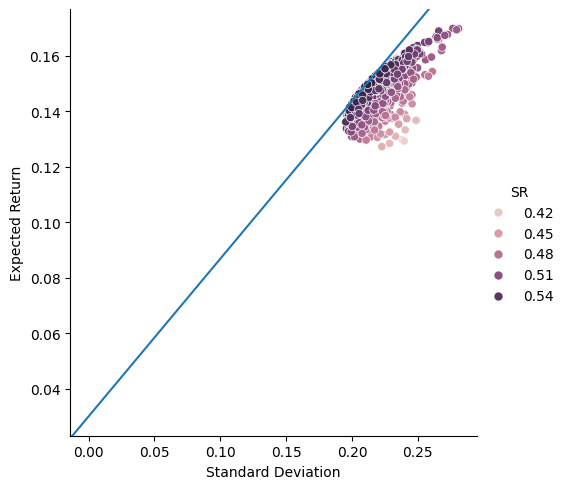

In [ ]:
# Extracting the optimised mean, standard deviation and SR from the data frame:
reverse_optimised_MV_coords = [reverse_MVO_portfolio_df['portfolio_std'][0], reverse_MVO_portfolio_df['portfolio_return'][0], reverse_MVO_portfolio_df['portfolio_sharpe_ratio'][0]]

# Generating 1000 other mean and standard deviation co-ordinate pairs using randomised weights:
reverse_MV_coords = []

for i in range(1000):

  # Generating random weights:
  other_weights = np.random.rand(len(equilibrium_returns_array))
  other_weights = other_weights / sum(other_weights)

  # Computing summary statistics:
  mean = np.dot(other_weights, np.array(equilibrium_returns_array).T)
  variance = np.dot(other_weights, np.dot(covariance_matrix, other_weights.T))
  std_dev = np.sqrt(variance)
  SR = (mean - risk_free_rate) / std_dev

  # Adding to list of co-ordinates:
  reverse_MV_coords.append([std_dev, mean, SR])

# Creating a data frame from the generated co-ordinates:
data = pd.DataFrame(reverse_MV_coords, columns=['std', 'mean', 'SR'])

# Generating a scatter plot of mean against standard deviation, with SR as hue:
reverse_MV_plot = sns.relplot(data, x='std', y='mean', hue='SR')
reverse_MV_plot.set_axis_labels('Standard Deviation', 'Expected Return')

# Additional line to mark on optimal SR:
reverse_MV_plot.ax.axline(xy1=(0, risk_free_rate), slope=reverse_MVO_portfolio_df['portfolio_sharpe_ratio'][0])






## Black-Litterman Model

Both MVO and reverse optimisation implicitly assume that the expected returns and covariances of constituent assets are stationary, assumptions which may not be true under changing regimes.

If an investor believes that the forward looking return for any asset may be different from its historical return, then the Black-Litterman (BL) model (Black & Litterman, 1992) can account for this.

The BL model formula is as follows:

$E(R_p) = [(\tau\Sigma)^{-1} + P^{T}\Omega^{-1}P]^{-1}[(\tau\Sigma)^{-1}\Pi + P^{T}\Omega^{-1}Q]$

Where:

$E(R_p) = $ expected portfolio return

$\tau = $ scalar to weight covariances of asset excess returns

$\Sigma = $ covariance matrix of excess returns

$P = $ weights of assets involved in discretionary views

$\Omega = $ diagonal covariance matrix of variances (uncertainties) of discretionary views

$\Pi = $ equilibrium return vector from reverse optimisation

$Q = $ vector of investor-forecasted returns

As explained in (Idzorek 2005, p. 13), the model is in effect a sophisticated weighted average of equilibrium returns derived from historical data and an investor's forward looking projections.

The BL model can also be implemented using the PyPortfolioOpt package.

Given the requisite inputs, the BL function we will use is coded below:


In [ ]:
def black_litterman_return(tau, covariance_matrix, views_weights_matrix, views_returns_vector, view_uncertainty_matrix, equilibrium_return_vector):

  # Handling errors at source:
  if tau <= 0:
    raise ValueError("tau must be a positive number")
  if np.linalg.det(covariance_matrix) == 0:
    raise ValueError("covariance_matrix must be non-singular")
  if len(views_weights_matrix) != len(views_returns_vector):
    raise ValueError("lengths of views_weights_matrix and views_returns_vector must match")
  if np.linalg.det(view_uncertainty_matrix) == 0:
    raise ValueError("view_uncertainty_matrix must be non-singular")
  if len(views_weights_matrix) != len(view_uncertainty_matrix):
    raise ValueError("lengths of views_weights_matrix and view_uncertainty_matrix must match")
  if len(covariance_matrix) != len(equilibrium_return_vector):
    raise ValueError("lengths of covariance_matrix and equilibrium_return_vector must match")
  if len(covariance_matrix) != max([len(covariance_matrix[i]) for i in range(len(covariance_matrix))]):
    raise ValueError("covariance_matrix is not square")
  if len(covariance_matrix) != min([len(covariance_matrix[i]) for i in range(len(covariance_matrix))]):
    raise ValueError("covariance_matrix is not square")

  # Converting lists to arrays:
  covariance_matrix = np.array(covariance_matrix)
  views_weights_matrix = np.array(views_weights_matrix)
  views_returns_vector = np.array(views_returns_vector)
  view_uncertainty_matrix = np.array(view_uncertainty_matrix)
  equilibrium_return_vector = np.array(equilibrium_return_vector)

  # Building up the formula:
  tau_sigma_inverse = np.linalg.inv(tau * covariance_matrix)
  p_transpose_sigma_inverse = np.dot(views_weights_matrix.T, np.linalg.inv(view_uncertainty_matrix))

  bl_first_half = np.linalg.inv(tau_sigma_inverse + np.dot(p_transpose_sigma_inverse, views_weights_matrix))
  bl_second_half = np.dot(tau_sigma_inverse, equilibrium_return_vector.T) + np.dot(p_transpose_sigma_inverse, views_returns_vector.T)

  return np.dot(bl_first_half, bl_second_half)

As noted by Idzorek (p. 14), the $\tau$ parameter is the most ambiguous and values for it in calculation by others have included small decimals to reduce tracking error, $1$, or $\frac{1}{n}$ where $n = $ number of observations, the latter to account for the standard errors of the covariance matrix.

Here we will take $\tau = 1$ to give equal weighting to the equilibrium and discretionary returns (after weighting by their uncertainties).

This author does not believe accounting for standard error for $\Sigma$ is necessary as there is no corrective analogue for $\Omega$ and this would lead to a dimensional imbalance.

In any case, if the outputs from the BL model are undesirable, then this may say more about the inputs for $\Omega$, $P$ and $Q$ than any attempt to rebalance the formula towards the equilibrium returns through adjusting $\tau$.

To form forward-looking views on our stocks (as a reminder: GOOGL, TGT, NKE, V, GM), let us first look again at their equilibrium returns:

In [ ]:
equilibrium_df = pd.DataFrame(equilibrium_returns_array)
equilibrium_df.index = ['GOOGL', 'TGT', 'NKE', 'V', 'GM']
equilibrium_df.columns = ['equilibrium_return']

print(equilibrium_df)
print('mean_return = {}'.format(equilibrium_df['equilibrium_return'].mean()))

       equilibrium_return
GOOGL            0.140959
TGT              0.117287
NKE              0.149868
V                0.132701
GM               0.192030
mean_return = 0.14656885861566857


The month of writing is February 2026 and perhaps we view Google's expected return as on the low side, particularly relative to General Motors' return, which is the highest of the 5 stocks.

Perhaps GM's revenue may be hit in future by tariff costs and for Google to capture more gains from its investment in AI than is suggested by its equilibrium return.

On the other hand, the equilibrium returns for all stocks here are above the long-run return of the S&P 500 of 10% and so perhaps we should adjust all returns downward for a sustainable forward-looking market view.

Putting concrete numbers on these views, let's reduce the current average of 14.66% by 400bps to a forward looking average of 10.66% by reducing all stocks by that amount.

Then to implement relative views, we will increase GOOGL's return by 300bps and decrease GM's return by 300bps.

So far, this results in values for $P$ and $Q$ as follows:

In [ ]:
P = [[-1, -1, -1, -1, -1], [1, 0, 0, 0, -1]]
Q = [0.04, 0.03]

To estimate variances for the matrix $\Omega$, Idzorek (p. 13) suggests calculating $P_{i} \Sigma P_{i}^{T}$ where $P_{i}$ is row $i$ from $P$.

Implementing this results in the following $2 \times 2$ matrix for $\Omega$:

In [ ]:
# Converting P to an array, initialising Omega:
P = np.array(P)
omega = []

# Populating Omega with variance calculations:
for i in range(len(P)):
  omega.append(np.dot(np.dot(P[i], covariance_matrix), P[i].T).tolist())

# Converting Omega into a diagonal matrix:
omega = np.array(omega)
omega = np.diag(omega)

print(omega)

[[1.11400555 0.        ]
 [0.         0.14530988]]


This would be consistent with being more confident that GOOGL will outperform GM, but less confident that the average of the 5 stocks will return to levels around the long-run S&P 500 average.

For comparison, below is the annualised covariance matrix for our 5 stocks:

In [ ]:
print(np.array(covariance_matrix))

[[0.07446276 0.02105368 0.02892984 0.02724304 0.03445557]
 [0.02105368 0.10414591 0.03566718 0.01995783 0.03566631]
 [0.02892984 0.03566718 0.0962253  0.03260629 0.0495339 ]
 [0.02724304 0.01995783 0.03260629 0.04798262 0.04060171]
 [0.03445557 0.03566631 0.0495339  0.04060171 0.13975826]]


Finally, below is the ouput from the BL model:

In [ ]:
# Obtaining BL returns list:
bl_return = black_litterman_return(1, covariance_matrix, P, Q, omega, equilibrium_returns_array)

# Display as a data frame:
bl_df = pd.DataFrame(bl_return)
bl_df.index = ['GOOGL', 'TGT', 'NKE', 'V', 'GM']
bl_df.columns = ['bl_returns']

print(bl_df)

       bl_returns
GOOGL    0.083618
TGT      0.041673
NKE      0.064395
V        0.073596
GM       0.074829


## Final Remarks

This project has presented an exposition of MVO and its variants, using a hard-coding approach instead of using library packages available such as `scipy.optimize`, `PyPortfolioOpt` or `CVXPY`.

This had the disadvantage of messier code, but the advantage of seeing the individual algorithms at work, seeing what went on "under the hood".

A further advantage was greater customisation, particularly in the method using $n$-dimensional spherical polars.

The reader may have noticed that the less sophisticated method of "trial and error" may have yielded superior results for MVO as points at the very edge of the efficient frontier were missed out.

Trial and error may be the winner over gradient descent for this example, but the trade-off could also be inefficiency as the number of assets is increased and the success of trial and error also depends on the assumption for the distribution of the random weights, whereas gradient descent makes no such assumption.

In any case, the author has no regret over having chosen interesting theory above practical accuracy for the purposes of demonstrating a novel approach.

#References

Black, F. and Litterman, R. (1992). “Global Portfolio Optimization.” Financial Analysts Journal, September/October, 28-43.

CFA Institute (2026) "Asset Allocation: CFA Program Curriculum, 2026 Level III Core, Volume 1". For candidate use only. Not for distribution.

Idzorek, T. (2019) "A Step-By-Step Guide to the Black-Litterman Model Incorporating User-specified Confidence Levels" (November 3, 2019). Available at SSRN: https://ssrn.com/abstract=3479867 or http://dx.doi.org/10.2139/ssrn.3479867 (Accessed 10 Feb 2026)